# Hashtag Frequency Visualization System
**Tiny Project: Social Media Analytics and Sentiment Analysis**

Harit Mengar | Enrollment No. 2305101010055 | M.Sc. Machine Learning and AI

## 1. Aim

Hashtags are how people group posts by topic on social media, but nobody can read thousands of posts to see which topics are actually popular. The aim of this project is simple:

1. Pull the hashtags out of a set of posts
2. Count how often each one appears
3. Check whether the posts using a hashtag are mostly positive or negative
4. Show all of this in charts that are easy to read

I kept the scope small on purpose since this is a tiny project. The same code works on any CSV that has a `text` column, so it can be pointed at real data later.

## 2. Dataset

I could not use the Twitter/X API because access is now paid, so I generated a synthetic dataset of 500 posts with `generate_sample_data.py`. Each post has an id, a timestamp (spread over 30 days in September 2026) and some text with one to three hashtags. The topics (AI, Python, Cricket, Food and so on) are weighted so that some are more common than others, similar to how real feeds behave.

**Important:** because the data is synthetic, the numbers below only show that the pipeline works. They are not real-world findings about what people post.

## 3. Setup

In [2]:
%pip install vaderSentiment wordcloud
import re
from collections import Counter
from itertools import combinations

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

  Obtaining dependency information for vaderSentiment from https://files.pythonhosted.org/packages/76/fc/310e16254683c1ed35eeb97386986d6c00bc29df17ce280aed64d55537e9/vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata
  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)
Note: you may need to restart the kernel to use updated packages.


## 4. Loading the data

In [3]:
df = pd.read_csv("data/posts.csv")
df["date"] = pd.to_datetime(df["date"])
print(df.shape)
df.head()

(500, 3)


,id,date,text
0,1,2026-09-09 07:00:00,Our team played brilliantly #Cricket
1,2,2026-09-24 17:00:00,Love how clean this ML pipeline turned out #Ma...
2,3,2026-09-07 07:00:00,AI is changing how we work #AI #Fitness
3,4,2026-09-07 22:00:00,Beautiful dashboard shipped today #DataScience
4,5,2026-09-09 00:00:00,Our team played brilliantly #Cricket #DataScie...


In [4]:
# quick sanity check before doing anything else
print(df.isna().sum())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

id      0
date    0
text    0
dtype: int64
Date range: 2026-09-01 to 2026-09-30


## 5. Extracting hashtags

A regular expression `#(\w+)` grabs every word that follows a `#`. I convert them to lowercase so that `#AI` and `#ai` are treated as the same hashtag.

In [5]:
HASHTAG_RE = re.compile(r"#(\w+)")

def extract_hashtags(text):
    return [t.lower() for t in HASHTAG_RE.findall(text)]

df["hashtags"] = df["text"].apply(extract_hashtags)
df[["text", "hashtags"]].head()

,text,hashtags
0,Our team played brilliantly #Cricket,[cricket]
1,Love how clean this ML pipeline turned out #Ma...,[machinelearning]
2,AI is changing how we work #AI #Fitness,"[ai, fitness]"
3,Beautiful dashboard shipped today #DataScience,[datascience]
4,Our team played brilliantly #Cricket #DataScie...,"[cricket, datascience, food]"


In [6]:
print("Average hashtags per post:", round(df["hashtags"].apply(len).mean(), 2))
print("Posts with no hashtag:", (df["hashtags"].apply(len) == 0).sum())

Average hashtags per post: 1.94
Posts with no hashtag: 0


## 6. Hashtag frequency

In [7]:
counts = Counter(tag for tags in df["hashtags"] for tag in tags)
freq = pd.DataFrame(counts.most_common(), columns=["hashtag", "count"])
print("Unique hashtags:", len(freq))
freq

Unique hashtags: 10


,hashtag,count
0,ai,137
1,python,118
2,machinelearning,106
3,food,100
4,startup,95
5,datascience,89
6,tech,89
7,cricket,86
8,travel,85
9,fitness,67


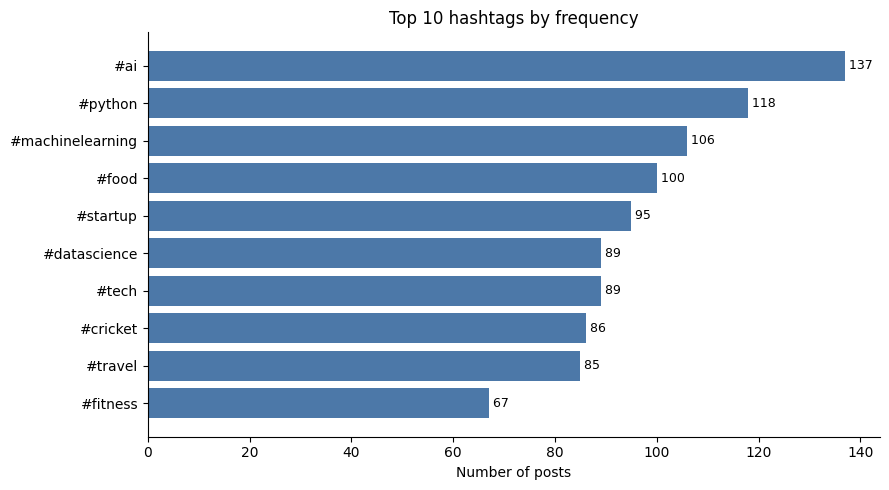

In [8]:
top = freq.head(10).iloc[::-1]
plt.barh("#" + top["hashtag"], top["count"], color="#4C78A8")
for y, v in enumerate(top["count"]):
    plt.text(v, y, f" {v}", va="center", fontsize=9)
plt.xlabel("Number of posts")
plt.title("Top 10 hashtags by frequency")
plt.tight_layout()
plt.show()

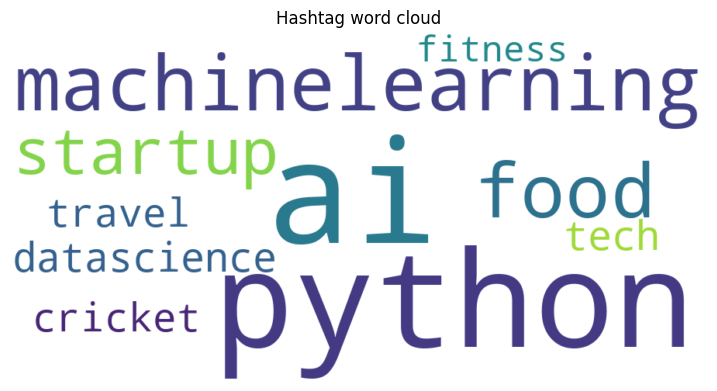

In [9]:
wc = WordCloud(width=900, height=450, background_color="white").generate_from_frequencies(counts)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Hashtag word cloud")
plt.show()

## 7. Sentiment analysis

For sentiment I used **VADER**. It is a rule-based model made for short social media text, it needs no training and it runs fast. It gives a *compound* score from -1 (very negative) to +1 (very positive). The usual cutoffs are above 0.05 for positive and below -0.05 for negative, anything in between is neutral.

One thing I noticed: if the hashtags are left in the text, they get scored as words too, which can add noise. So I strip them out before scoring.

In [10]:
analyzer = SentimentIntensityAnalyzer()

clean_text = df["text"].apply(lambda t: HASHTAG_RE.sub("", t))
df["sentiment"] = clean_text.apply(lambda t: analyzer.polarity_scores(t)["compound"])
df["label"] = pd.cut(df["sentiment"], [-1.01, -0.05, 0.05, 1.01],
                     labels=["Negative", "Neutral", "Positive"])

df[["text", "sentiment", "label"]].sample(5, random_state=1)

,text,sentiment,label
304,Best trip of the year #Travel #DataScience,0.6369,Positive
340,AI hype is getting out of hand #AI #Fitness,0.4939,Positive
47,Struggling with model overfitting again #Machi...,-0.4215,Negative
67,Excited about the new AI models #AI,0.3400,Positive
479,Excited about the new AI models #AI #Travel,0.3400,Positive


label
Positive    312
Negative    128
Neutral      60
Name: count, dtype: int64


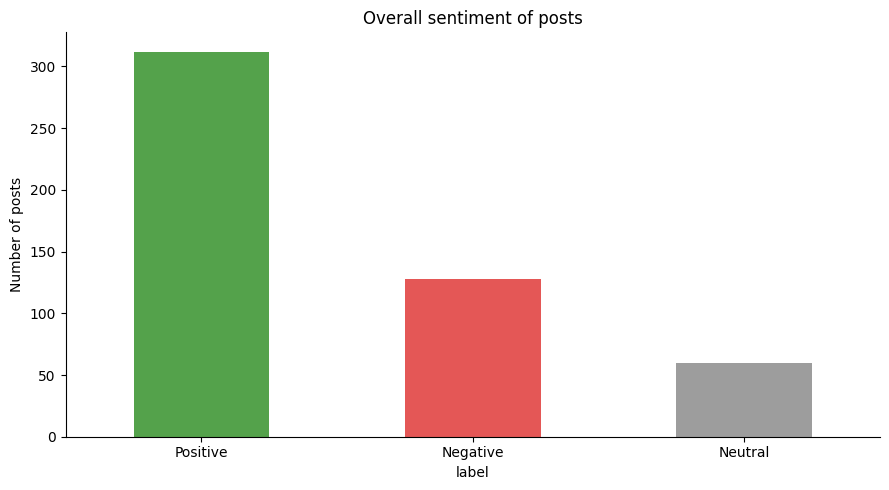

In [11]:
label_counts = df["label"].value_counts()
print(label_counts)
label_counts.plot(kind="bar", color=["#54A24B", "#E45756", "#9D9D9D"], rot=0)
plt.title("Overall sentiment of posts")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

### Sentiment per hashtag

A post can have more than one hashtag, so I use `explode()` to make one row per (post, hashtag) pair. Then I take the mean sentiment for each hashtag.

In [12]:
exploded = df.explode("hashtags").dropna(subset=["hashtags"])
tag_sent = (exploded.groupby("hashtags")["sentiment"]
            .agg(avg_sentiment="mean", posts="count")
            .sort_values("posts", ascending=False)
            .head(10)
            .round(3))
tag_sent

,avg_sentiment,posts
hashtags,,
ai,0.300,137
python,0.224,118
machinelearning,0.272,106
food,0.191,100
startup,0.316,95
datascience,0.128,89
tech,0.201,89
cricket,0.340,86
travel,0.262,85


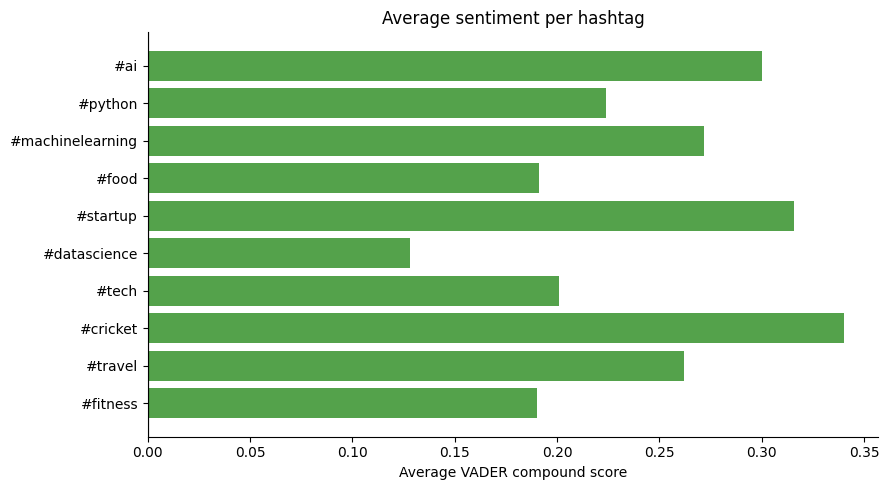

In [13]:
d = tag_sent.iloc[::-1]
colors = ["#54A24B" if v > 0.05 else "#E45756" if v < -0.05 else "#9D9D9D" for v in d["avg_sentiment"]]
plt.barh("#" + d.index, d["avg_sentiment"], color=colors)
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Average VADER compound score")
plt.title("Average sentiment per hashtag")
plt.tight_layout()
plt.show()

## 8. Hashtags used together

In [14]:
pairs = Counter()
for tags in df["hashtags"]:
    for a, b in combinations(sorted(set(tags)), 2):
        pairs[(a, b)] += 1

pair_df = pd.DataFrame([(f"#{a} + #{b}", c) for (a, b), c in pairs.most_common(10)],
                       columns=["pair", "count"])
pair_df

,pair,count
0,#ai + #python,22
1,#ai + #food,21
2,#ai + #cricket,19
3,#cricket + #python,19
4,#ai + #tech,19
5,#food + #python,18
6,#startup + #tech,18
7,#ai + #startup,17
8,#ai + #travel,17
9,#datascience + #food,16


## 9. Trend over time

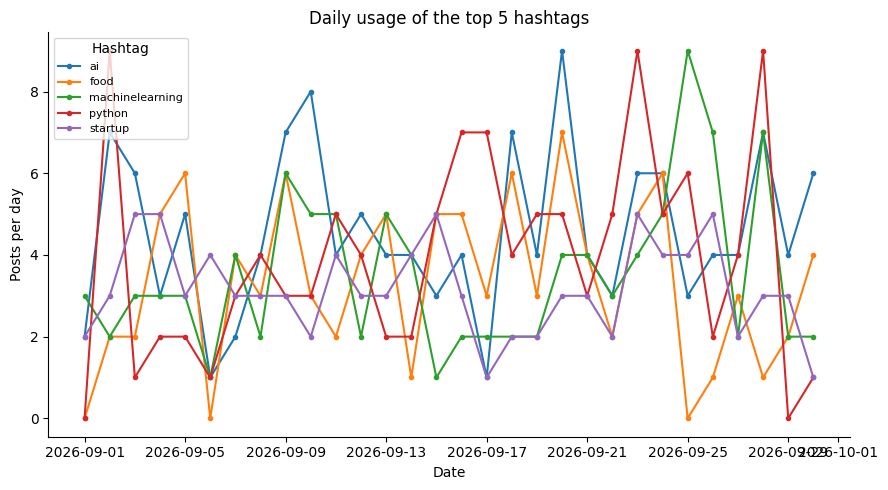

In [15]:
top5 = list(freq["hashtag"].head(5))
sub = exploded[exploded["hashtags"].isin(top5)].copy()
sub["day"] = sub["date"].dt.date
trend = sub.groupby(["day", "hashtags"]).size().unstack(fill_value=0)

trend.plot(marker="o", ms=3)
plt.title("Daily usage of the top 5 hashtags")
plt.xlabel("Date")
plt.ylabel("Posts per day")
plt.legend(title="Hashtag", fontsize=8)
plt.tight_layout()
plt.show()

## 10. Observations

- **#ai** is the most used hashtag with 137 posts, followed by **#python** (118) and **#machinelearning** (106). This matches the weights I set when generating the data, which is a good sign that the extraction and counting are correct.
- About 62% of the posts (312 out of 500) came out positive and around 26% negative. The overall average sentiment is about 0.24.
- Every hashtag has a positive average score, from about 0.13 for **#datascience** to 0.34 for **#cricket**. Positive and negative posts are mixed inside each hashtag, so the averages hide a lot of variation.
- The most frequent pair is **#ai + #python** (22 posts). The pair counts are close to each other because the co-occurring tags in my data were picked at random, so there is no real pattern to find here. In real data this section would be more interesting.
- The daily trend lines are noisy and do not show a clear rise or fall, which is expected for random data.

## 11. Limitations

- The dataset is synthetic, so none of the findings say anything real about social media.
- VADER is lexicon based. It does not understand sarcasm, slang or mixed-language posts (a lot of Indian social media mixes Hindi and English, which it would handle badly).
- Averaging sentiment per hashtag treats every post equally and ignores likes, reposts and reach.
- Hashtags are only matched on spelling, so `#ML` and `#MachineLearning` are counted as different tags even though they mean the same thing.

## 12. Future work

- Collect real posts (Reddit or Mastodon have free APIs) and rerun the same pipeline
- Try a transformer model such as a Twitter-RoBERTa sentiment model and compare it with VADER
- Group similar hashtags together, for example with embeddings
- Detect trending hashtags automatically by comparing this week with last week

## 13. Conclusion

The system takes a CSV of posts, extracts and counts the hashtags, scores sentiment and shows everything as charts. It also comes with a Streamlit dashboard (`app.py`) for trying it on other files. It works end to end on the sample data, and the next real step is to test it on live data.